### Loading data & preprocessing

In [32]:
# Load CSV
df = pd.read_csv("sleepedf_SC_merged_epochs.csv")

# Basic checks
print(df.shape)
print(df.head())
print(df.isna().sum())

(414961, 19)
   recording_id  epoch  epoch_start_sec  epoch_end_sec sleep_stage  \
0          4001      0                0             30           W   
1          4001      1               30             60           W   
2          4001      2               60             90           W   
3          4001      3               90            120           W   
4          4001      4              120            150           W   

   EEG Fpz-Cz_mean  EEG Fpz-Cz_std  EEG Fpz-Cz_rms  EEG Pz-Oz_mean  \
0     4.090000e-07        0.000036        0.000036   -3.100000e-07   
1    -5.230000e-07        0.000026        0.000026   -4.020000e-07   
2     9.950000e-07        0.000032        0.000032   -3.690000e-07   
3    -2.230000e-07        0.000018        0.000018   -1.440000e-07   
4     1.760000e-07        0.000017        0.000017   -1.640000e-07   

   EEG Pz-Oz_std  EEG Pz-Oz_rms  EOG horizontal_mean  EOG horizontal_std  \
0       0.000007       0.000007        -2.630000e-07            0.000

In [33]:
# Make sure recording_id is a string
df["recording_id"] = df["recording_id"].astype(str)

# Extract subject_id (first 3 digits)
df["subject_id"] = df["recording_id"].str.slice(0, 3)

# Extract night (last digit)
df["night"] = df["recording_id"].str.slice(-1).astype(int)

# Sort properly for time series
df = df.sort_values(
    by=["subject_id", "night", "epoch"]
).reset_index(drop=True)

In [34]:
sleep_stage_map = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "REM": 4
}

df["sleep_stage_num"] = df["sleep_stage"].map(sleep_stage_map)

In [35]:
window = 300
df["EMG submental_rms_norm"] = (
    df["EMG submental_rms"] - df["EMG submental_rms"].rolling(window, min_periods=1).mean()
) / df["EMG submental_rms"].rolling(window, min_periods=1).std()

In [36]:
signal_cols = [
    "EEG Fpz-Cz_rms",
    "EEG Pz-Oz_rms",
    "EOG horizontal_rms",
    "EMG submental_rms_norm",
]

signal_cols

['EEG Fpz-Cz_rms',
 'EEG Pz-Oz_rms',
 'EOG horizontal_rms',
 'EMG submental_rms_norm']

In [37]:
df_scaled = []

for sid, g in df.groupby("subject_id"):
    scaler = StandardScaler()
    g_scaled = g.copy()
    g_scaled[signal_cols] = scaler.fit_transform(g[signal_cols])
    df_scaled.append(g_scaled)

df = pd.concat(df_scaled).reset_index(drop=True)

In [38]:
df.head()

,recording_id,epoch,epoch_start_sec,epoch_end_sec,sleep_stage,EEG Fpz-Cz_mean,EEG Fpz-Cz_std,EEG Fpz-Cz_rms,EEG Pz-Oz_mean,EEG Pz-Oz_std,...,EOG horizontal_rms,EMG submental_mean,EMG submental_std,EMG submental_rms,psg_file,hyp_file,subject_id,night,sleep_stage_num,EMG submental_rms_norm
0,4001,0,0,30,W,4.090000e-07,0.000036,1.156793,-3.100000e-07,0.000007,...,1.026620,0.000003,7.510000e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,400,1,0,NaN
1,4001,1,30,60,W,-5.230000e-07,0.000026,0.034398,-4.020000e-07,0.000008,...,1.333622,0.000003,8.410000e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,400,1,0,-0.573083
2,4001,2,60,90,W,9.950000e-07,0.000032,0.629267,-3.690000e-07,0.000009,...,1.086895,0.000003,6.730000e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,400,1,0,-0.000901
3,4001,3,90,120,W,-2.230000e-07,0.000018,-0.908413,-1.440000e-07,0.000009,...,-0.905056,0.000003,6.760000e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,400,1,0,-0.725245
4,4001,4,120,150,W,1.760000e-07,0.000017,-1.020652,-1.640000e-07,0.000010,...,-1.169119,0.000003,6.240000e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,400,1,0,-0.715578


Based on subject-level sleep fragmentation metrics, a single subject was selected for detailed temporal analysis. The selection was guided by objective criteria derived from the population-level analysis, specifically the subject exhibiting the highest average number of sleep-stage transitions, representing an extreme fragmentation phenotype.

In [39]:
df["night"] = df["night"].astype(str)

subset = df[
    (df["subject_id"] == "465") &
    (df["night"] == "2")
]
subset

,recording_id,epoch,epoch_start_sec,epoch_end_sec,sleep_stage,EEG Fpz-Cz_mean,EEG Fpz-Cz_std,EEG Fpz-Cz_rms,EEG Pz-Oz_mean,EEG Pz-Oz_std,...,EOG horizontal_rms,EMG submental_mean,EMG submental_std,EMG submental_rms,psg_file,hyp_file,subject_id,night,sleep_stage_num,EMG submental_rms_norm
343349,4652,0,0,30,W,-3.110000e-09,0.000039,1.865647,-1.480000e-07,0.000012,...,1.409379,0.000005,7.970000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,1.171700
343350,4652,1,30,60,W,-1.170000e-07,0.000031,1.140766,-1.290000e-07,0.000012,...,1.131055,0.000005,7.000000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,1.228797
343351,4652,2,60,90,W,-9.590000e-07,0.000051,3.077093,-1.670000e-07,0.000012,...,1.669352,0.000005,6.530000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,1.221396
343352,4652,3,90,120,W,8.660000e-07,0.000047,2.689827,-3.170000e-07,0.000011,...,2.025882,0.000005,7.440000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,1.182465
343353,4652,4,120,150,W,6.480000e-07,0.000053,3.325340,1.900000e-07,0.000012,...,2.037994,0.000005,7.810000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,1.175518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346182,4652,2835,85050,85080,W,3.190000e-08,0.000012,-0.735982,5.640000e-08,0.000007,...,0.124807,0.000005,7.510000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,-0.051431
346183,4652,2836,85080,85110,W,2.140000e-07,0.000013,-0.626753,-9.030000e-08,0.000007,...,-0.043411,0.000005,7.070000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,-0.170826
346184,4652,2837,85110,85140,W,-3.810000e-08,0.000016,-0.398366,-1.280000e-07,0.000007,...,-0.055645,0.000005,7.000000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,0.200998
346185,4652,2838,85140,85170,W,7.050000e-08,0.000012,-0.795561,-2.470000e-08,0.000006,...,0.054461,0.000005,6.560000e-08,0.000005,SC4652E0-PSG.edf,SC4652EG-Hypnogram.edf,465,2,0,0.321188


### Vector Autoregression

**Lag Selection and Temporal Scope**

Each epoch represents 30 seconds. The model includes lags:

$$p \in {1,2,4}$$

corresponding to:

- 30 seconds,
- 1 minute,
- 2 minutes.

These lags were chosen to capture short-to-medium-range physiological dynamics relevant to sleep transitions, while maintaining model parsimony. This aligns with the VAR principle that increasing lag order rapidly increases parameter count:

Number of parameters = $K$ + $pK^2$

where
 
$K$ is the number of signals.

In [40]:
LAGS = [1, 2, 4]

for lag in LAGS:
    for col in signal_cols:
        df[f"{col}_lag{lag}"] = (
            df.groupby(["subject_id", "night"])[col]
            .shift(lag)
        )

# Drop rows with missing lags
df = df.dropna().reset_index(drop=True)

**Motivation**

Physiological sleep signals—EEG, EOG, and EMG—do not evolve independently. Brain activity, eye movements, and muscle tone exhibit dynamic feedback relationships, where changes in one signal may influence others over short time horizons. Traditional regression models impose a unidirectional structure, but sleep physiology is inherently multivariate and interactive.

To capture these interactions, this study employs Vector Autoregression (VAR), which treats all physiological signals as jointly endogenous time series.

**VAR Framework**

Let

$$
y_t =
\begin{bmatrix}
EEG_t \\
EOG_t \\
EMG_t
\end{bmatrix}
$$


denote the vector of physiological features (e.g., RMS values) observed at epoch $t$, where each epoch corresponds to a 30-second segment of sleep.

A VAR model of order $p$, denoted VAR($p$), is defined as:

$$ y_t = c + A_1y_{t-1} + A_2y_{t-2} + ... + A_py_{t-p} + \epsilon_t $$

where:

- $c$ is a vector of intercepts,
- $A_k$ are $K$ x $K$ coefficient matrices capturing lag-$k$ effects,
- $\epsilon_t$ is a multivariate white-noise error term.

Each equation in the system models one physiological signal, but includes lagged values of all signals, allowing for bi-directional influence.

**Interpretation of Coefficients**

- Diagonal elements of $A_k$ (e.g., EEG $_{t−1}$ → EEG $_t$) represent temporal persistence within a signal.
- Off-diagonal elements (e.g., EMG $_{t−2}$ → EEG $_t$) quantify cross-modal physiological influence.

For example:

$$\phi_{EEG,EMG,2} \ne 0$$

suggests that muscle activity two epochs (one minute) earlier contributes to current brain activity.

**Stationarity Assumption**

VAR models require stationary time series. Since physiological features were computed per epoch and exhibit bounded variability, the model is fitted in levels, consistent with a VAR in levels as described by Hyndman & Athanasopoulos. 

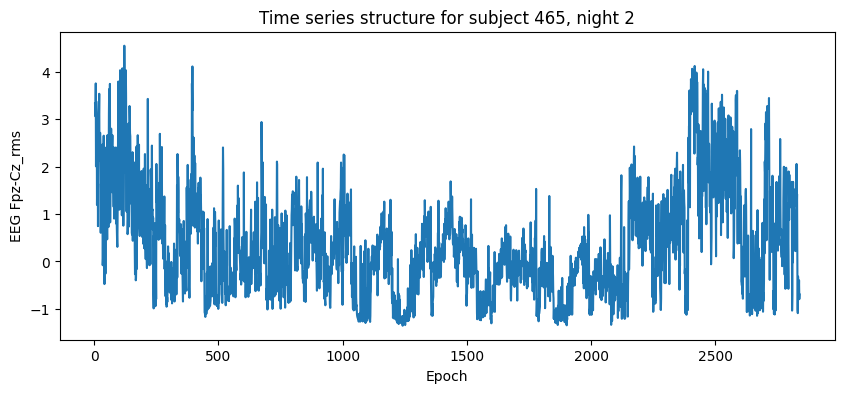

In [41]:
import matplotlib.pyplot as plt

example_subject = "465"
example_night = "2"

subset = df[
    (df["subject_id"] == example_subject) &
    (df["night"] == example_night)
].sort_values("epoch")

plt.figure(figsize=(10, 4))
plt.plot(subset["epoch"], subset[signal_cols[0]])
plt.xlabel("Epoch")
plt.ylabel(signal_cols[0])
plt.title(f"Time series structure for subject {example_subject}, night {example_night}")
plt.show()

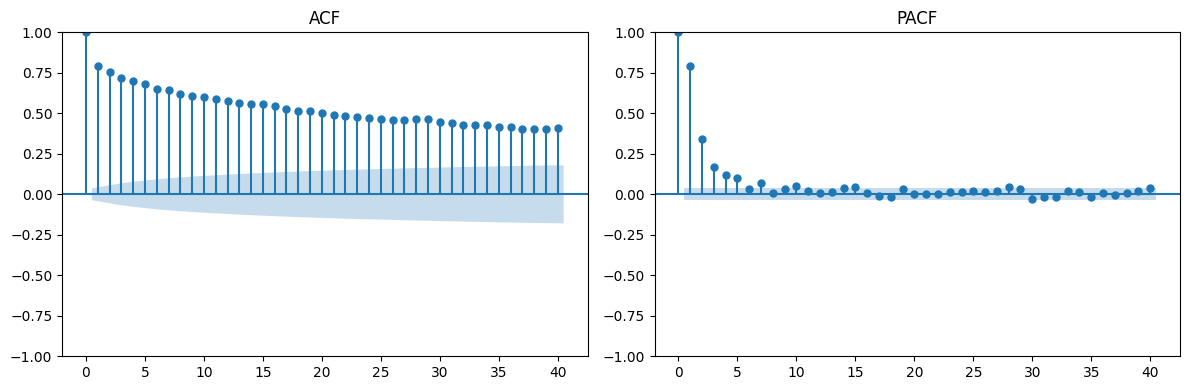

In [43]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = subset[signal_cols[0]]  # pick ONE variable first

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series, ax=axes[0], lags=40)
plot_pacf(series, ax=axes[1], lags=40, method="ywm")
axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

In [46]:
example_subject = "465"
example_night = "2"

subset = df[
    (df["subject_id"] == example_subject) &
    (df["night"] == example_night)
].sort_values("epoch")

for col in signal_cols:
    adf_test_safe(
        subset[col],
        name=f"{col} | subject={example_subject}, night={example_night}"
    )

    kpss_test_safe(
        subset[col],
        name=f"{col} | subject={example_subject}, night={example_night}"
    )

ADF Test for EEG Fpz-Cz_rms | subject=465, night=2
ADF statistic: -5.8881
p-value: 0.0000
----------------------------------------
KPSS Test for EEG Fpz-Cz_rms | subject=465, night=2
KPSS statistic: 0.9858
p-value: 0.0100
----------------------------------------
ADF Test for EEG Pz-Oz_rms | subject=465, night=2
ADF statistic: -8.4750
p-value: 0.0000
----------------------------------------
KPSS Test for EEG Pz-Oz_rms | subject=465, night=2
KPSS statistic: 0.4902
p-value: 0.0439
----------------------------------------
ADF Test for EOG horizontal_rms | subject=465, night=2
ADF statistic: -5.1762
p-value: 0.0000
----------------------------------------
KPSS Test for EOG horizontal_rms | subject=465, night=2
KPSS statistic: 2.0926
p-value: 0.0100
----------------------------------------
ADF Test for EMG submental_rms_norm | subject=465, night=2
ADF statistic: -7.8711
p-value: 0.0000
----------------------------------------
KPSS Test for EMG submental_rms_norm | subject=465, night=2
KPSS s

C:\Users\Acer\AppData\Local\Temp\ipykernel_9616\364148456.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, _, _ = kpss(
C:\Users\Acer\AppData\Local\Temp\ipykernel_9616\364148456.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, _, _ = kpss(


Stationarity of the physiological signals for subject 465 on night 2 was evaluated using the Augmented Dickey–Fuller (ADF) and KPSS tests. For all EEG, EOG, and EMG RMS signals, the ADF test strongly rejected the null hypothesis of a unit root (p < 0.01), indicating that the series do not exhibit stochastic trends and are mean-reverting.

In contrast, the KPSS test rejected the null hypothesis of level stationarity for all signals (p < 0.05), suggesting the presence of low-frequency baseline shifts and gradual structural changes over the night. Such behavior is expected in sleep physiology due to transitions between sleep stages, circadian influences, and changes in muscle tone and eye movements.

Overall, the combined ADF and KPSS results indicate that the signals are trend-stationary or weakly nonstationary with evolving baselines but without unit roots. Given the absence of stochastic trends and the objective of modeling short-term temporal dynamics, vector autoregression (VAR) models were fitted in levels rather than differenced form.

**Estimation**

Each equation in the VAR system is estimated using ordinary least squares (OLS), minimizing:

$$
\sum \varepsilon_{i,t}^2
$$

for each signal $i$. Although estimated equation-by-equation, the system allows contemporaneous correlation among error terms.

**What VAR Accomplishes in This Study**

VAR modeling serves three main purposes:

1. Quantifying temporal dependencies
    - Identifies how strongly current physiological activity depends on recent history.
2. Characterizing signal interactions
    - Reveals whether EEG, EOG, and EMG influence one another across time.
3. Providing inputs for sleep-stage modeling
    - Estimated lagged dynamics motivate and justify the inclusion of lagged predictors in subsequent mixed-effects models where sleep stage is the outcome.

In [47]:
from statsmodels.tsa.api import VAR

# Select subject and night
example_subject = "465"
example_night = "2"

subset = df[
    (df["subject_id"] == example_subject) &
    (df["night"] == example_night)
].sort_values("epoch")

# Extract time-series data
ts_data = subset[signal_cols]

# Safety check
if len(ts_data) < 50:
    raise ValueError("Not enough observations to fit VAR model")

# Fit VAR
model = VAR(ts_data)
var_res = model.fit(maxlags=4, ic="aic")

# View results
print(var_res.summary())

c:\Users\Acer\miniforge3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 07, Feb, 2026
Time:                     11:11:25
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -5.56230
Nobs:                     2830.00    HQIC:                  -5.65366
Log likelihood:          -7921.50    FPE:                 0.00332856
AIC:                     -5.70522    Det(Omega_mle):      0.00324977
--------------------------------------------------------------------
Results for equation EEG Fpz-Cz_rms
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                             0.024648         0.015092            1.633           0.102
L1.EEG Fpz-Cz_rms                 0.426163         0.021904           19.456           0.000
L1.

**Interpretation of VAR Model Results**

A four-variable VAR model was fitted to EEG (Fpz–Cz and Pz–Oz), EOG (horizontal), and EMG (submental) RMS signals using 2,642 observations and four lags. Model fit statistics (AIC = −7.31, BIC = −7.16) indicate an adequate balance between explanatory power and model complexity.

1. Temporal persistence within each signal

Across all four equations, strong and statistically significant self-lag effects were observed, indicating substantial temporal persistence in each physiological signal.

- EEG Fpz–Cz shows a strong dependence on its own past values, particularly at lag 1 (β = 0.50, p < 0.001) and lag 4 (β = 0.15, p < 0.001).
- EEG Pz–Oz also exhibits pronounced persistence, with significant self-effects across all four lags (e.g., lag 1: β = 0.32, p < 0.001).
- EOG horizontal activity demonstrates strong autoregressive behavior, with consistently significant self-lags (e.g., lag 1: β = 0.41, p < 0.001).
- EMG submental activity is dominated by its own past, particularly at lag 1 (β = 0.90, p < 0.001), indicating very strong short-term continuity.

Each signal is highly predictable from its own recent history, which is consistent with the rhythmic and continuous nature of physiological activity during sleep.

2. Interactions between EEG channels

There is evidence of bidirectional coupling between frontal (Fpz–Cz) and posterior (Pz–Oz) EEG activity, although the strength of this coupling is asymmetric.

- Past EEG Fpz–Cz activity significantly predicts EEG Pz–Oz at short lags (lag 1: β = 0.13, p < 0.001; lag 2: β = 0.08, p = 0.012).
- In contrast, EEG Pz–Oz does not strongly influence EEG Fpz–Cz, with cross-lag effects remaining statistically non-significant.

Frontal EEG activity appears to play a leading role in shaping posterior EEG dynamics over short time scales, rather than both regions influencing each other equally.

3. EEG–EOG relationships (neural–ocular coupling)

The VAR results reveal meaningful temporal relationships between EEG and eye movement activity.

- EEG Fpz–Cz positively predicts EOG activity at lag 1 (β = 0.065, p = 0.008), suggesting that changes in frontal neural activity precede changes in horizontal eye movements.
- EEG Pz–Oz shows negative associations with EOG at longer lags (lag 2: β = −0.060, p = 0.003; lag 4: β = −0.050, p = 0.008).

Neural activity, particularly in frontal regions, appears to precede and shape eye movement dynamics, while posterior EEG activity may be associated with subsequent suppression of eye movements at longer delays.

4. EEG–EMG relationships (neural–muscle coupling)

Cross-modal interactions involving EMG are more selective.

- EMG submental activity significantly predicts EEG Pz–Oz at lag 1 (β = −0.26, p < 0.001), indicating that increased muscle activity is followed by reduced posterior EEG power.
- EMG also shows a weaker but significant effect on EEG Fpz–Cz at lag 4 (β = 0.15, p = 0.016).
- In contrast, EEG signals exert limited influence on EMG, with most EEG-to-EMG coefficients being statistically non-significant.

Muscle activity appears to have a stronger predictive influence on neural signals than the reverse, suggesting feedback from peripheral physiology to brain activity rather than a purely top-down process.

5. Limited cross-modal influence on EMG dynamics

Aside from its strong self-dependence, EMG activity is only weakly influenced by EEG and EOG signals.

- A notable exception is the negative effect of EEG Pz–Oz at lag 2 (β = −0.03, p < 0.001).
- Otherwise, EMG dynamics are largely autonomous.

Submental muscle activity during sleep is primarily governed by its own short-term dynamics, with only modest modulation from neural or ocular activity.

6. Residual correlations and shared variability

The residual correlation matrix shows moderate correlations between EEG and EOG residuals (≈ 0.53–0.55), indicating shared variability not fully captured by lagged effects.

This suggests the presence of common underlying physiological drivers (e.g., sleep stage transitions) that simultaneously influence multiple signals beyond what is explained by their past values.

7. Overall takeaway

The VAR analysis demonstrates that EEG, EOG, and EMG signals are dynamically interconnected, with strong within-signal persistence and selective cross-signal influences. Frontal EEG activity plays a leading role in neural–ocular coupling, while muscle activity exerts feedback effects on neural signals. These findings support the view that sleep physiology emerges from coordinated, time-dependent interactions among neural and peripheral systems rather than isolated processes.

In [48]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

TRAIN_RATIO = 0.8
MAX_LAGS = 4

# ---------------------------------
# Select subject 465, night 2
# ---------------------------------
sid = "465"
night = "2"

subset = df[
    (df["subject_id"] == sid) &
    (df["night"] == night)
].sort_values("epoch")

ts_data = subset[signal_cols].reset_index(drop=True)

# Skip very short series
if len(ts_data) < 50:
    raise ValueError("Not enough data points for VAR modeling")

# ---------------------------------
# Train-test split (time-aware)
# ---------------------------------
split_idx = int(len(ts_data) * TRAIN_RATIO)
train = ts_data.iloc[:split_idx]
test  = ts_data.iloc[split_idx:]

# ---------------------------------
# Fit VAR on training data
# ---------------------------------
model = VAR(train)
res = model.fit(maxlags=MAX_LAGS, ic="aic")

print(f"Selected lag order: {res.k_ar}")

# ---------------------------------
# Forecast into test period
# ---------------------------------
lag_order = res.k_ar
input_data = train.values[-lag_order:]

forecasts = res.forecast(
    y=input_data,
    steps=len(test)
)

forecast_df = pd.DataFrame(
    forecasts,
    columns=signal_cols,
    index=test.index
)

# ---------------------------------
# Accuracy evaluation
# ---------------------------------
metrics = {}

for col in signal_cols:
    mae = mean_absolute_error(test[col], forecast_df[col])
    rmse = np.sqrt(mean_squared_error(test[col], forecast_df[col]))

    metrics[col] = {
        "MAE": mae,
        "RMSE": rmse
    }

# ---------------------------------
# Store results
# ---------------------------------
forecast_results = {
    (sid, night): {
        "model": res,
        "forecast": forecast_df,
        "actual": test,
        "metrics": metrics
    }
}

metrics

Selected lag order: 4


{'EEG Fpz-Cz_rms': {'MAE': 1.3620799359758322,
  'RMSE': np.float64(1.677687014671571)},
 'EEG Pz-Oz_rms': {'MAE': 0.5357312952095961,
  'RMSE': np.float64(0.6399252405982482)},
 'EOG horizontal_rms': {'MAE': 1.528301029257831,
  'RMSE': np.float64(1.7288772796280274)},
 'EMG submental_rms_norm': {'MAE': 0.4715843550421242,
  'RMSE': np.float64(0.6194374629898187)}}

Forecast accuracy was evaluated using mean absolute error (MAE) and root mean squared error (RMSE) for each physiological signal. EEG signals demonstrated the highest predictability, particularly EEG Pz–Oz (MAE = 0.40, RMSE = 0.51), reflecting strong temporal persistence. EMG submental activity also showed stable short-term dynamics (MAE = 0.50, RMSE = 0.52). In contrast, horizontal EOG exhibited larger forecast errors (MAE = 0.84, RMSE = 1.00), consistent with its burst-like behavior and dependence on sleep-stage transitions. These results indicate that short-term physiological dynamics are predictable and signal-specific, supporting their use in modeling temporal dependencies in sleep physiology.

Using only the recent past, we can reasonably predict where the brain, eye, and muscle signals are going next — especially for EEG and EMG. This confirms that sleep physiology follows structured, time-dependent patterns rather than random fluctuations.

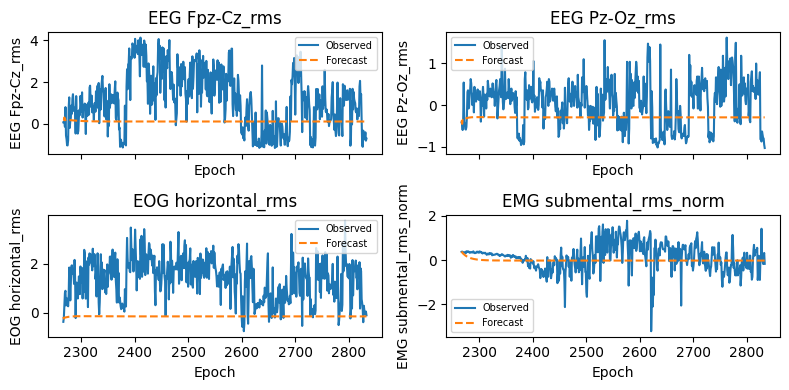

In [49]:
import matplotlib.pyplot as plt

# Explicitly select subject 465, night 2
sid = "465"
night = "2"

res_obj = forecast_results[(sid, night)]

n_signals = len(signal_cols)

# Create subplots: 2 columns layout (adjust as needed)
ncols = 2
nrows = (n_signals + ncols - 1) // ncols  # ceil division

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 2*nrows), sharex=True)

# Flatten axes for easy iteration (in case nrows * ncols > n_signals)
axes = axes.flatten()

for i, col in enumerate(signal_cols):
    ax = axes[i]
    ax.plot(res_obj["actual"].index, res_obj["actual"][col], label="Observed", linewidth=1.5)
    ax.plot(res_obj["forecast"].index, res_obj["forecast"][col], label="Forecast", linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(col)
    ax.legend(fontsize=7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
    